In [1]:
import pickle
import pandas as pd
import copy
import numpy as np
import scipy.stats as stats
import ast
import seaborn as sns
from matplotlib import colors
import matplotlib.pyplot as plt

from _helper_functions import cb
from _helper_functions import dprint
from _helper_functions import zipdf
from _helper_functions import quickfig

In [2]:
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'

allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq',drop=False)
allDF.head()

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL351560,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAGATATTAAGATAGGA,ORL108031,L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,ORL414244,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL280162,L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [3]:
activeEnsDepGataEts=allDF['enhancer-dependent-gata-ets']==1
inert=allDF['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<=0
unclassified = (allDF['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']<=1) & (allDF['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']>=0)
allDF=allDF.loc[activeEnsDepGataEts | inert | unclassified,:] # everything but active and not dependent on GATA/ETS

In [4]:
fn='reference-files/OlsEnSeq2Id.pydict.pickle'
with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
dprint(OlsEnSeq2Id)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA Otx-a WT


In [5]:
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [6]:
OLSName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSName2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [7]:
with open('reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle','rb') as f:OLSName2SyntaxFamily=pickle.load(f)
with open('reference-files//SyntaxFamily2OLSName-vary-aff.pydict.pickle','rb') as f:SyntaxFamily2OLSName=pickle.load(f)    

In [8]:
dprint(SyntaxFamily2OLSName)

L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6 {'L1-G2R-L2-E1F-L3-E2F-L4-G1R-L5-G3F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G3R-L5-G1F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G1R-L5-G3F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G2R-L5-G1F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G2R-L5-G1F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G2R-L5-G3F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G1R-L5-G2F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G1R-L5-G2F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G3R-L5-G2F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G3R-L5-G1F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G3R-L5-G2F-L6'}


In [9]:
dprint(OLSName2SyntaxFamily)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


# Generate (or load) Syntax Family Data

In [10]:
# if running for the first time 

activityColumn='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0
idxSet=set(allDF.index)

synFamilies=[]
allFuncEns=[]
allNonFuncEns=[]
enFuncCounts=[]
enNonfuncCounts=[]
SyntaxFamily2Info={} # number functional and nonfunctional

for synFam,synVariants in SyntaxFamily2OLSName.items():

    synFamActivities=[]
    for tfbsList in synVariants:
        
        en=OLSName2Seq[tfbsList]
        
        if en in idxSet:  activity=allDF.at[en,activityColumn]
        else:             activity=0
            
        synFamActivities.append(activity)
        
        
    nonFuncCounts=sum([i<=thresholdToLabelNegatives for i in synFamActivities])
    funcCounts   =sum([i>=thresholdToLabelPositives for i in synFamActivities])
    
    if funcCounts==12:      
        allFuncEns.append(synFam)
        
    if nonFuncCounts==12:   
        allNonFuncEns.append(synFam)
    
    enFuncCounts.append(funcCounts)
    enNonfuncCounts.append(nonFuncCounts)
    synFamilies.append(synFam)
    
    SyntaxFamily2Info[synFam]=(funcCounts,nonFuncCounts)
    

c2v={'syntax-family':synFamilies,'n-func':enFuncCounts,'n-inert':enNonfuncCounts,'n-func-inert-tuple':[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]}
famDF=pd.DataFrame(c2v)
# famDF.to_csv('F03-Syntax-Families/syntax-fam-table-real-data_depGE.tsv',index=None,sep='\t')
famDF.head()

In [12]:
# if you already have the file
famDF=pd.read_csv('F03-Syntax-Families//syntax-fam-table-real-data_depGE.tsv',sep='\t')

In [13]:
Bin2RealCount={}

for nfunc,ninert in zipdf(famDF,['n-func','n-inert']):
    if (nfunc,ninert) not in Bin2RealCount:
        Bin2RealCount[nfunc,ninert]=0
    Bin2RealCount[nfunc,ninert]+=1
        

# Generate (or load) Permuted Syntax Family Data

In [14]:
npermutations=100

In [15]:
# if running for the first time 

activityColumn='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0
idxSet=set(allDF.index)

for permuteIter in range(npermutations):
    
    print(permuteIter,end=',  ')
    
    permEnhancers=np.random.permutation(allDF['wt-enhancer-seq'])
    allDF['wt-enhancer-seq']=permEnhancers
    allDF=allDF.set_index('wt-enhancer-seq',drop=False)

    
    synFamilies=[]
    allFuncEns=[]
    allNonFuncEns=[]
    enFuncCounts=[]
    enNonfuncCounts=[]
    SyntaxFamily2Info={} # number functional and nonfunctional
    for synFam,synVariants in SyntaxFamily2OLSName.items():


        synFamActivities=[]
        for tfbsList in synVariants:
            en=OLSName2Seq[tfbsList]

            if en in idxSet:  activity=allDF.at[en,activityColumn]
            else:             activity=0

            synFamActivities.append(activity)


        nonFuncCounts=sum([i<=thresholdToLabelNegatives for i in synFamActivities])
        funcCounts   =sum([i>=thresholdToLabelPositives for i in synFamActivities])

        if funcCounts==12:      
            allFuncEns.append(synFam)

        if nonFuncCounts==12:   
            allNonFuncEns.append(synFam)

        enFuncCounts.append(funcCounts)
        enNonfuncCounts.append(nonFuncCounts)
        synFamilies.append(synFam)

        SyntaxFamily2Info[synFam]=(funcCounts,nonFuncCounts)

    famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]

famDF.to_pickle(f'F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters={npermutations}_depGE.pd.df.pickle')
famDF.to_csv(   f'F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters={npermutations}_depGE.tsv',sep='\t',index=None)

In [16]:
famDF=pd.read_pickle(f'F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters={npermutations}_depGE.pd.df.pickle')

In [17]:
famDF.head(1)

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,1,5,"(1, 5)","(0, 5)","(1, 7)","(1, 8)","(3, 5)","(1, 5)","(2, 5)",...,"(1, 7)","(0, 6)","(1, 4)","(0, 9)","(1, 7)","(2, 5)","(1, 7)","(1, 7)","(2, 8)","(0, 8)"


In [18]:
# z-normalize counts 

# get raw ccounts
Bin2NullCountList={}

for col in [ci for ci in famDF.columns if 'n-func-inert-tuple-permute' in ci]:
    
    bin2count={bi : famDF[col].tolist().count(bi) for bi in famDF[col].unique()}
    
    for bi,count in bin2count.items():
        if bi not in Bin2NullCountList:
            Bin2NullCountList[bi]=[]
        Bin2NullCountList[bi].append(count)


In [19]:
allBins=set()
for i in range(0,13):
    for j in range(0,13):
        if i+j<=12:
            allBins.add((i,j))
            allBins.add((j,i))

In [20]:
realBinsDetected=set(famDF['n-func-inert-tuple'].unique())
permutedBinsDetected=set(Bin2NullCountList.keys())

undetectedBins=allBins-realBinsDetected-permutedBinsDetected

In [21]:
# get z normalizing info

Bin2Info={bi:{'std':np.std(Bin2NullCountList[bi]), 'mean':np.mean(Bin2NullCountList[bi]), 'median':np.median(Bin2NullCountList[bi])} for bi in Bin2NullCountList}

dprint(Bin2Info,5)

print()

#  z  normalize real data

Bin2RealZ={}

bin2realcount={bi : famDF['n-func-inert-tuple'].tolist().count(bi) for bi in famDF['n-func-inert-tuple'].unique()}

for bi in famDF['n-func-inert-tuple'].unique():

    # if bin has data from permuted in it (not all do)
    if bi not in Bin2Info:
        Bin2RealZ[bi]=np.inf
        
    else:
        Bin2RealZ[bi] = ( bin2realcount[bi] - Bin2Info[bi]['mean'] ) / Bin2Info[bi]['std']
        

(0, 5) {'std': 29.254160387883292, 'mean': 1014.71, 'median': 1012.5}
(3, 6) {'std': 29.93973112771723, 'mean': 970.45, 'median': 968.5}
(1, 7) {'std': 52.13412989587531, 'mean': 3094.55, 'median': 3102.5}
(0, 6) {'std': 38.92342610819351, 'mean': 1654.87, 'median': 1656.5}
(1, 6) {'std': 48.987364697440086, 'mean': 3048.09, 'median': 3045.5}
(2, 5) {'std': 39.883173143570204, 'mean': 2043.35, 'median': 2042.0}



/scratch/solvason/job_5990576/ipykernel_3223799/1521129344.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  Bin2RealZ[bi] = ( bin2realcount[bi] - Bin2Info[bi]['mean'] ) / Bin2Info[bi]['std']


In [22]:
# if bins were not observed, this is the most extreme result. Thereore we replace these with the most sig Z score.
maxz=max([i for i in Bin2RealZ.values() if  i!=np.inf])
for bi,zi in Bin2RealZ.items():
    if zi==np.inf:
        Bin2RealZ[bi]=maxz

In [23]:
minz=min(Bin2RealZ.values())

In [24]:
# convert z score to p value
Bin2RealP={(yi,xi):stats.norm.sf(abs(zi))*2 for (yi,xi),zi in Bin2RealZ.items()}
minp=min([i for i in Bin2RealP.values() if i>0])
Bin2RealP={(yi,xi):pi if pi>0 else minp for (yi,xi),pi in Bin2RealP.items()}

In [25]:
# adjust p values
Bin2RealPAdj={(yi,xi):pi*len(Bin2RealP) for (yi,xi),pi in Bin2RealP.items()}

In [26]:

ninertlist=[]
nfunclist=[]

for bi in Bin2Info:
    numOccurences=int(Bin2Info[bi]['mean'])
    nfunc=bi[0]
    ninert=bi[1]
    
    for i in range(numOccurences):
        nfunclist.append(nfunc)
        ninertlist.append(ninert)
        

/scratch/solvason/job_5990576/ipykernel_3223799/3452008693.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  heatmap1, xedges1, yedges1, im1 = ax[0].hist2d(x=famDF['n-inert'],y=famDF['n-func'],bins=range(15),cmap=plt.cm.get_cmap('rainbow'),cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax)#
/scratch/solvason/job_5990576/ipykernel_3223799/3452008693.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  heatmap2, xedges2, yedges2, im2 = ax[1].hist2d(x=ninertlist,y=nfunclist,bins=(xedges1, yedges1), cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax,cmap=plt.cm.get_cmap('rainbow'))


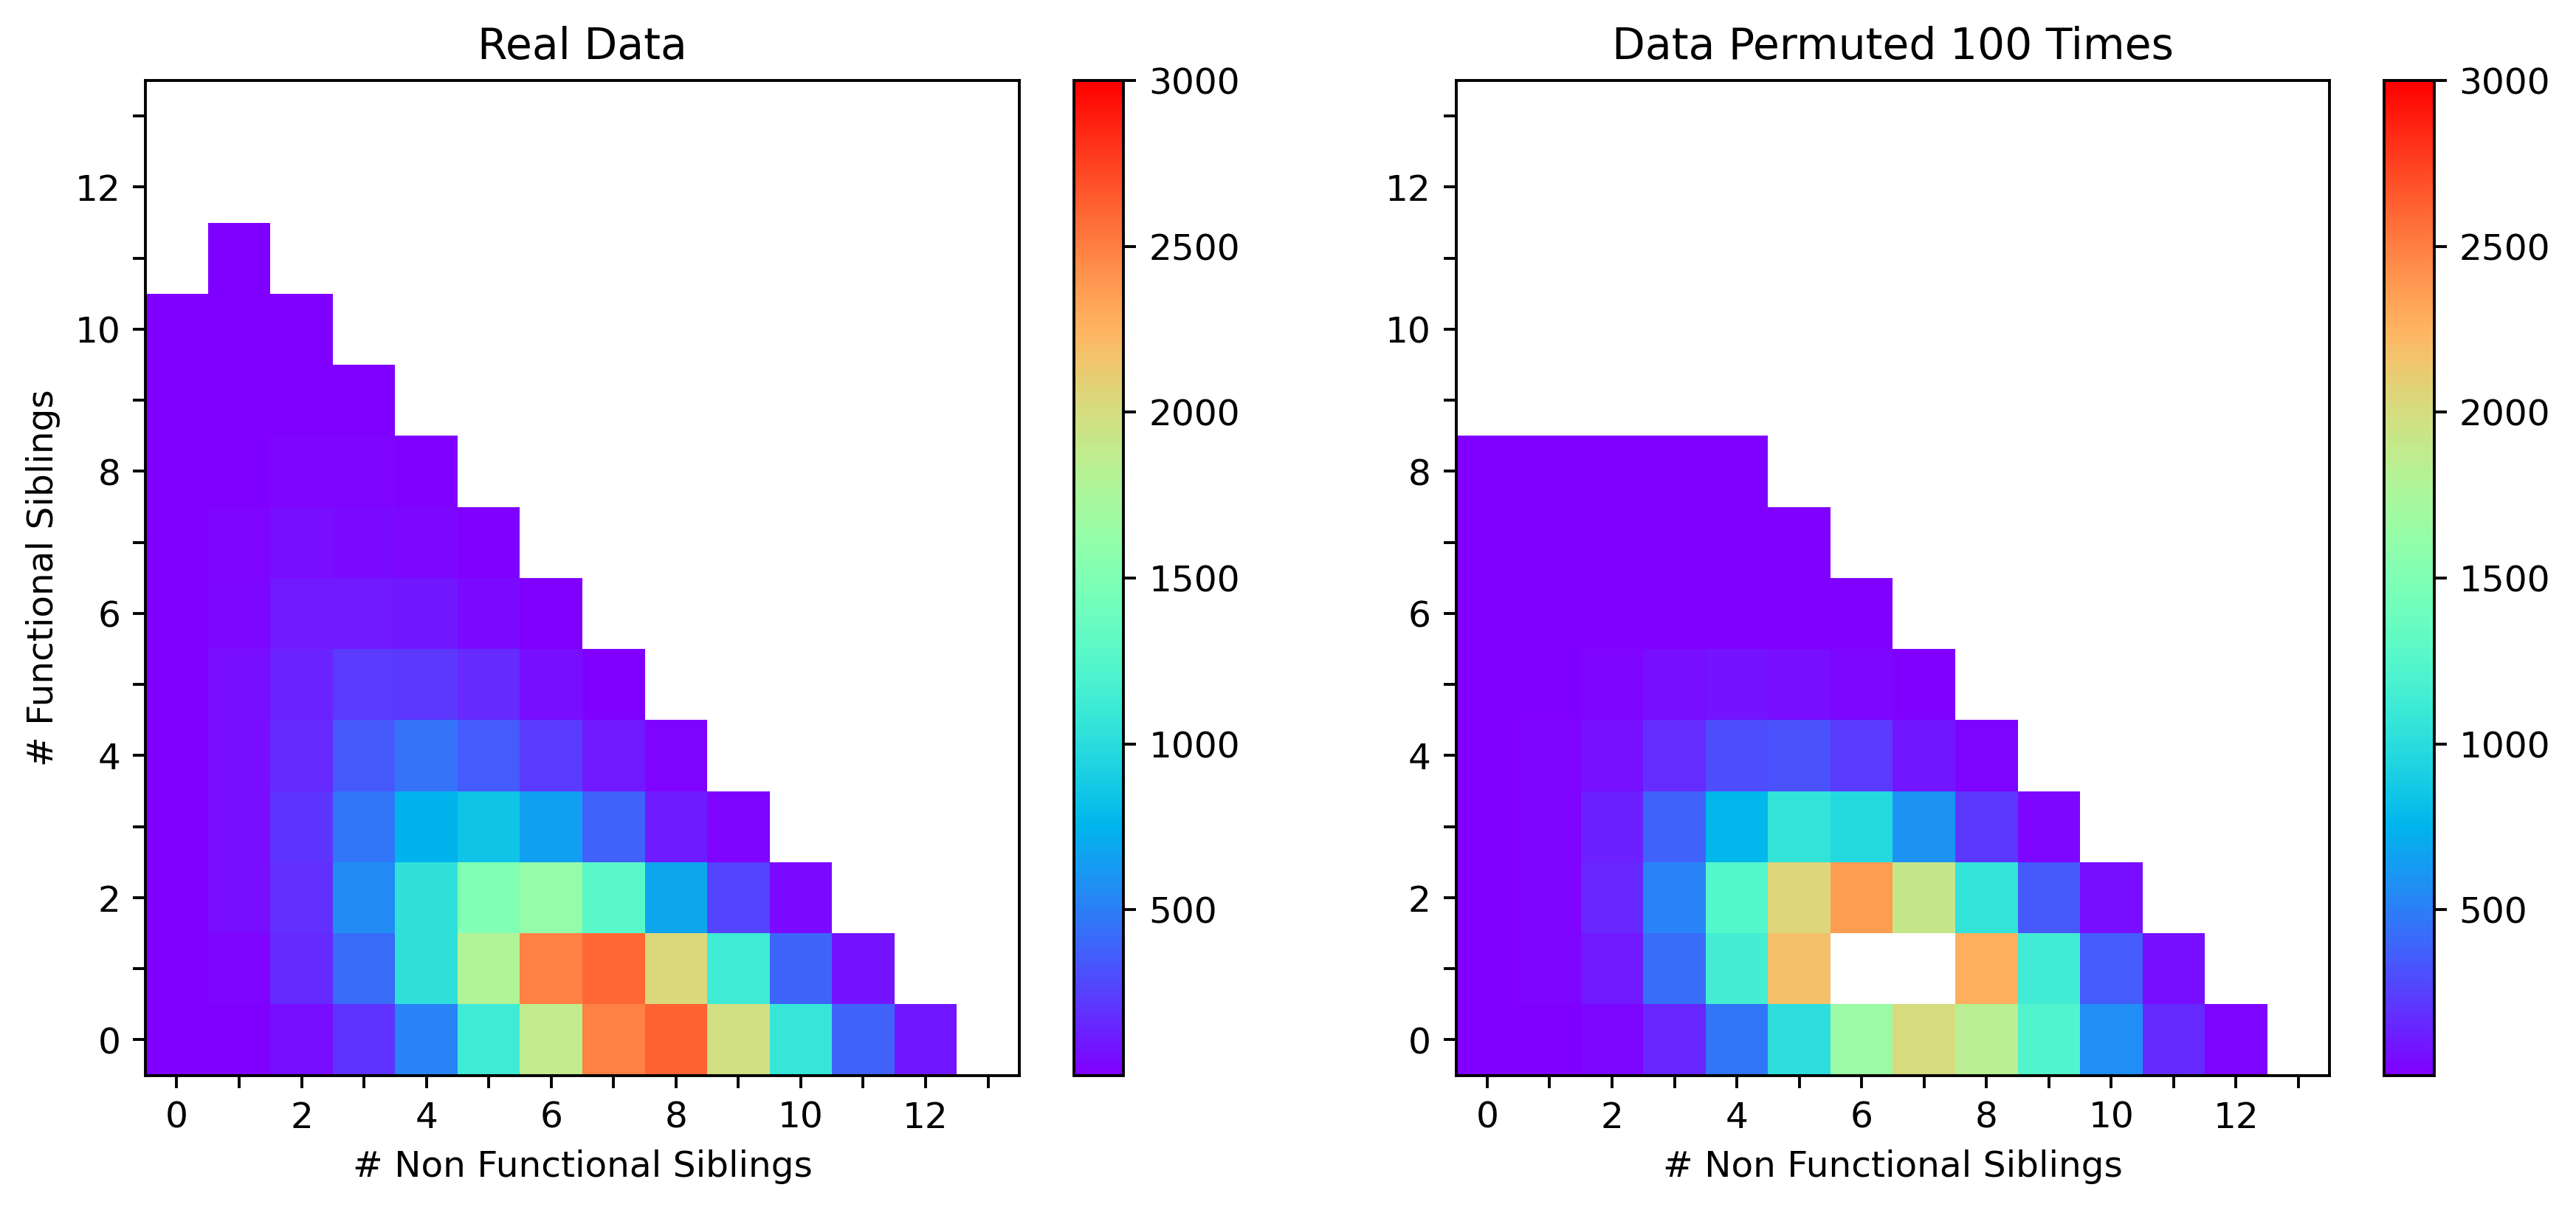

In [27]:
 
vmin=1
vmax=3000
cmin=vmin
cmax=vmax

fig,ax=plt.subplots(1, 2, figsize=(12, 5),dpi=350)

heatmap1, xedges1, yedges1, im1 = ax[0].hist2d(x=famDF['n-inert'],y=famDF['n-func'],bins=range(15),cmap=plt.cm.get_cmap('rainbow'),cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax)#

fig.colorbar(im1, ax=ax[0], orientation='vertical')        


ax[0].set_ylabel('# Functional Siblings')
ax[0].set_xlabel('# Non Functional Siblings')
ax[0].set_title('Real Data')

heatmap2, xedges2, yedges2, im2 = ax[1].hist2d(x=ninertlist,y=nfunclist,bins=(xedges1, yedges1), cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax,cmap=plt.cm.get_cmap('rainbow'))

ax[1].set_xlabel('# Non Functional Siblings')
ax[1].set_title(f'Data Permuted {npermutations} Times')


fig.colorbar(im1, ax=ax[1], orientation='vertical')        

for i in [0,1]:
    ticks=range(14)
    ax[i].set_yticks([t+.5 for t in ticks],labels=[t if t%2==0 else '' for t in ticks])
    ax[i].set_xticks([t+.5 for t in ticks],labels=[t if t%2==0 else '' for t in ticks])
        


In [28]:
with open('reference-files//syntax-fam-Bin2Annotation.pydict.pickle','rb') as f: 
    Bin2Annotation=pickle.load(f)
Bin2Annotation[10,2]='Moderate'

In [29]:
Annotation2Bins={anno:set() for anno in set(Bin2Annotation.values())}

for b,a in Bin2Annotation.items():
    
    Annotation2Bins[a].add(b)
    

In [30]:
anno2color={
    "":"white",
    "Inert":cb['orangenature'],
    "Moderate":'darkgrey',
    "Robust":cb['green'],
}


 	 622
Robust 	 14
Moderate 	 29,217
Inert 	 8,547


Text(0.5, 0, 'Number Inert Elements\nIn Family')

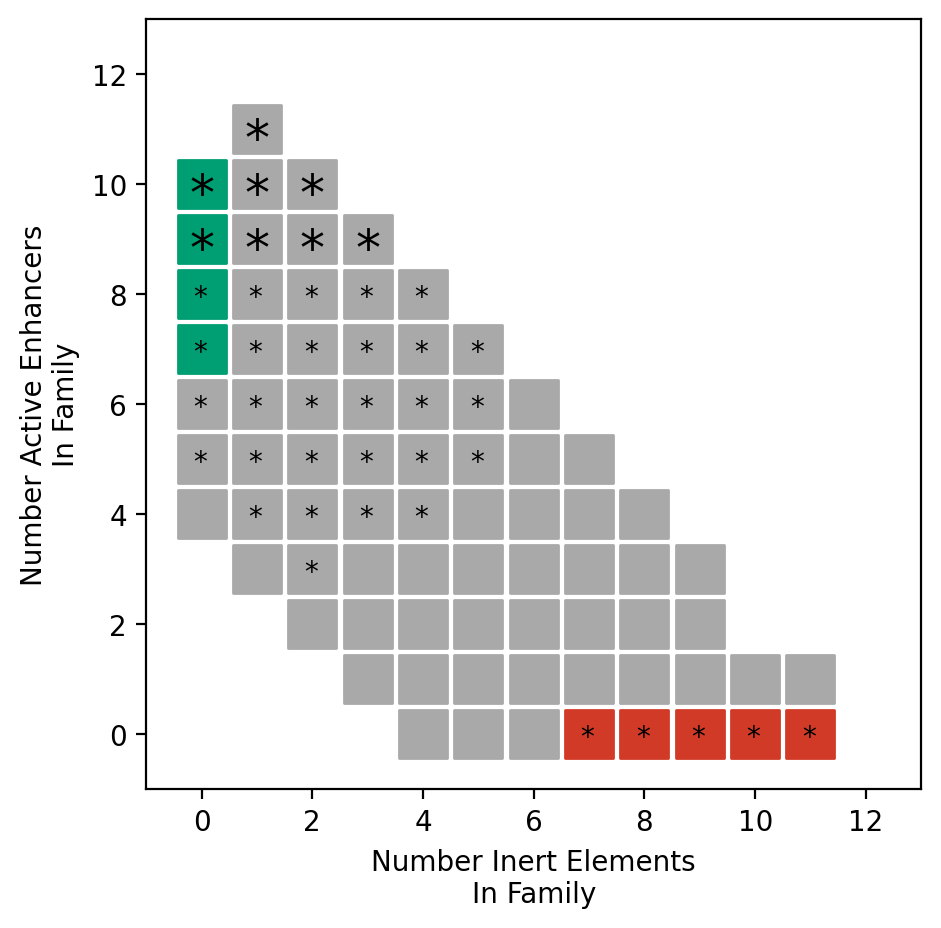

In [31]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

for y,x in Bin2Annotation:
    if (y,x) not in Bin2RealCount: continue
    anno=Bin2Annotation[y,x]
    color=anno2color[anno]
    
    ax.scatter(x,y,marker='s',color=color,s=300)
    
    if ((y,x) not in Bin2RealPAdj) or (anno==''): 
        p=1
        c=''

    else:                         
        p=Bin2RealPAdj[y,x]
        c=Bin2RealCount[y,x]
        if c>=1000:
            c=round(c/1000)
            c=f'{c}k'

    # if not observed at all, plot larger star
    if (y,x) not in Bin2NullCountList:
        ax.text(x,y-.2,'*',ha='center',va='center',size=18)
        
    elif p<1e-10 and Bin2RealZ[y,x]>0: 
        ax.text(x-.03,y-.06,'*',ha='center',va='center')


    
for anno,bins in Annotation2Bins.items():
    
    count=0
    for b in bins:
        if b not in Bin2RealCount: continue
        count+=Bin2RealCount[b]
        
    print(anno,'\t',f'{count:,}')
    
    
ax.set_ylim(-1,13)
ax.set_xlim(-1,13)

ax.set_yticks([0,2,4,6,8,10,12],labels=[0,2,4,6,8,10,12])
ax.set_xticks([0,2,4,6,8,10,12],labels=[0,2,4,6,8,10,12])

ax.set_ylabel('Number Active Enhancers\nIn Family')
ax.set_xlabel('Number Inert Elements\nIn Family')
